# Method 5 — Morphological Line Filtering / Top-Hat + Thresholding

**Pipeline**
```
CT image
→ white top-hat filtering with line structuring elements (multiple orientations)
→ combine orientations  (max response)
→ threshold
→ remove small round components
→ binary mask  (0 = background, 255 = crack)
```

The **white top-hat** transform (`image − morphological opening`) isolates bright structures that are *smaller than the structuring element*. With a **line-shaped** structuring element, it specifically enhances thin bright lines (cracks) while suppressing blobs and uniform background.

Applying the filter at multiple orientations and taking the pixel-wise maximum gives a rotation-invariant response map.

*"Morphological line-filter segmentation baseline."*

## Configuration

In [19]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
SAMPLES_DIR = Path("../samples")
OUTPUT_DIR  = Path("output/method5_morphological_tophat")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Line structuring element ───────────────────────────────────────────────
LINE_LENGTH      = 40    # length of each line SE in pixels (controls crack length sensitivity)
N_ORIENTATIONS   = 20    # number of angles spanning [0°, 180°)

# ── Thresholding ───────────────────────────────────────────────────────────
THRESHOLD_METHOD = "percentile"   # "percentile" | "otsu"
PERCENTILE       = 97.0           # used when THRESHOLD_METHOD == "percentile"

# ── Post-processing ────────────────────────────────────────────────────────
# Remove connected components whose bounding-box aspect ratio is too "round"
# (likely noise blobs, not crack segments).
MIN_COMPONENT_SIZE   = 100    # minimum pixels to keep
MIN_ASPECT_RATIO     = 2.0    # keep only components with major/minor axis ≥ this

print("Configuration loaded.")

Configuration loaded.


## Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import white_tophat, remove_small_objects, binary_closing, disk
from skimage.measure import label, regionprops

print("Imports OK.")

Imports OK.


## Pipeline functions

In [15]:
def load_grayscale(path: Path) -> np.ndarray:
    """Load image as float64 grayscale in [0, 1]."""
    img = io.imread(str(path))
    if img.ndim == 3:
        img = rgb2gray(img)
    return img_as_float(img)


def make_line_se(length: int, angle_deg: float) -> np.ndarray:
    """Create a boolean line structuring element of given length and orientation.

    The SE is a straight line of `length` pixels centred in a square footprint,
    rotated to `angle_deg`.  We draw it on a canvas using Bresenham's approach
    and rotate the whole footprint.
    """
    size = length + (1 if length % 2 == 0 else 0)  # ensure odd
    se = np.zeros((size, size), dtype=bool)
    mid = size // 2
    se[mid, :] = True   # horizontal line

    # Rotate by filling pixels along the rotated line direction
    angle_rad = np.deg2rad(angle_deg)
    se_rot = np.zeros((size, size), dtype=bool)
    cx, cy = mid, mid
    half = length // 2
    for t in range(-half, half + 1):
        r = int(round(cy + t * np.sin(angle_rad)))
        c = int(round(cx + t * np.cos(angle_rad)))
        if 0 <= r < size and 0 <= c < size:
            se_rot[r, c] = True
    return se_rot


def build_se_bank(n: int, length: int):
    """Return list of (angle_deg, SE) for n evenly-spaced orientations."""
    angles = np.linspace(0, 180, n, endpoint=False)
    return [(angle, make_line_se(length, angle)) for angle in angles]


def apply_tophat_bank(img: np.ndarray, se_bank) -> np.ndarray:
    """Apply white top-hat with each line SE and take the pixel-wise maximum.

    White top-hat = image - morphological_opening(image, SE).
    It isolates bright features (cracks) that fit within the SE footprint.
    Taking the max over orientations gives a rotation-invariant response.
    """
    responses = np.stack(
        [white_tophat(img, footprint=se) for _, se in se_bank],
        axis=0,
    )
    return responses.max(axis=0)


def threshold_response(response: np.ndarray) -> np.ndarray:
    """Convert the top-hat response map to a binary mask."""
    if THRESHOLD_METHOD == "percentile":
        pos = response[response > 0]
        if pos.size == 0:
            return np.zeros_like(response, dtype=bool)
        thresh = np.percentile(pos, PERCENTILE)
        return response > thresh
    elif THRESHOLD_METHOD == "otsu":
        return response > threshold_otsu(response)
    else:
        raise ValueError(f"Unknown threshold method: {THRESHOLD_METHOD!r}")


def remove_round_components(binary: np.ndarray) -> np.ndarray:
    """Remove small and overly round connected components.

    Top-hat with line SEs can still pick up small bright blobs (e.g. pores).
    We remove components that are:
      - smaller than MIN_COMPONENT_SIZE, OR
      - have major/minor axis ratio < MIN_ASPECT_RATIO  (too round to be a crack)
    """
    labeled = label(binary)
    out = np.zeros_like(binary, dtype=bool)
    for prop in regionprops(labeled):
        if prop.area < MIN_COMPONENT_SIZE:
            continue
        # minor_axis_length can be 0 for single-pixel components
        if prop.minor_axis_length == 0:
            continue
        aspect = prop.major_axis_length / prop.minor_axis_length
        if aspect < MIN_ASPECT_RATIO:
            continue
        out[labeled == prop.label] = True
    return out


def postprocess(binary: np.ndarray) -> np.ndarray:
    """Remove round/small blobs and lightly close gaps."""
    cleaned = remove_round_components(binary)
    return binary_closing(cleaned, footprint=disk(1))


def save_mask(mask: np.ndarray, out_path: Path) -> None:
    """Save boolean mask as 8-bit PNG (0 = background, 255 = crack)."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(out_path), (mask.astype(np.uint8)) * 255, check_contrast=False)


print("Functions defined.")

Functions defined.


## Visualise the line structuring element bank

Inspect the oriented line SEs before running on real images.

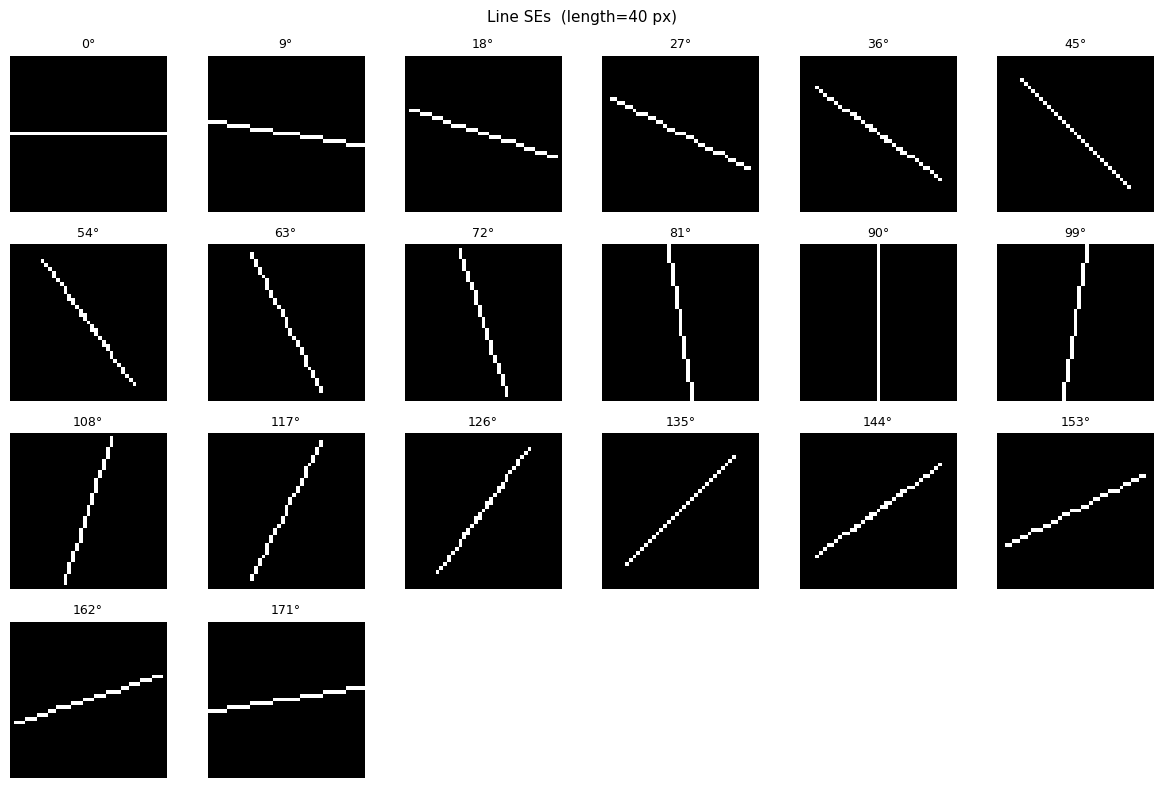

In [16]:
se_bank = build_se_bank(N_ORIENTATIONS, LINE_LENGTH)

cols = 6
rows = (N_ORIENTATIONS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()

for i, (angle, se) in enumerate(se_bank):
    axes[i].imshow(se, cmap="gray", interpolation="nearest")
    axes[i].set_title(f"{angle:.0f}°", fontsize=9)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Line SEs  (length={LINE_LENGTH} px)", fontsize=11)
plt.tight_layout()
plt.show()

## Run predictions on all samples

In [17]:
exts   = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
images = sorted(p for p in SAMPLES_DIR.iterdir() if p.suffix.lower() in exts)

print(f"SE length    : {LINE_LENGTH} px")
print(f"Orientations : {N_ORIENTATIONS}  (0° – {180 - 180 // N_ORIENTATIONS}°)")
print(f"Threshold    : {THRESHOLD_METHOD}" + (f"  (p={PERCENTILE})" if THRESHOLD_METHOD == "percentile" else ""))
print(f"Output dir   : {OUTPUT_DIR.resolve()}")
print(f"Images       : {len(images)}\n")

# Build SE bank once – reused for every image
se_bank = build_se_bank(N_ORIENTATIONS, LINE_LENGTH)

for img_path in images:
    print(f"  {img_path.name} ...", end=" ", flush=True)
    img      = load_grayscale(img_path)
    response = apply_tophat_bank(img, se_bank)
    binary   = threshold_response(response)
    mask     = postprocess(binary)
    out_path = OUTPUT_DIR / (img_path.stem + "_mask.png")
    save_mask(mask, out_path)
    print(f"-> {out_path.name}")

print("\nDone.")

SE length    : 40 px
Orientations : 20  (0° – 171°)
Threshold    : percentile  (p=97.0)
Output dir   : /Users/ramyar/Git/Realistic_Crack/Unsupervised methods/output/method5_morphological_tophat
Images       : 12

  front_0263_1A_220kv.png ... -> front_0263_1A_220kv_mask.png
  front_1100_3A_135kv.png ... -> front_1100_3A_135kv_mask.png
  front_1208_3A_220kv.png ... -> front_1208_3A_220kv_mask.png
  front_1210_1B_135kv.png ... -> front_1210_1B_135kv_mask.png
  front_1274_4A_135kv.png ... -> front_1274_4A_135kv_mask.png
  front_1629_1B_220kv.png ... -> front_1629_1B_220kv_mask.png
  front_1688_2B_220kv.png ... -> front_1688_2B_220kv_mask.png
  front_1851_2A_220kv.png ... -> front_1851_2A_220kv_mask.png
  front_2203_4A_220kv.png ... -> front_2203_4A_220kv_mask.png
  front_2265_2B_135kv.png ... -> front_2265_2B_135kv_mask.png
  front_2402_2A_135kv.png ... -> front_2402_2A_135kv_mask.png
  front_4292_6.png ... -> front_4292_6_mask.png

Done.


## Visual inspection — image | top-hat response | binary mask

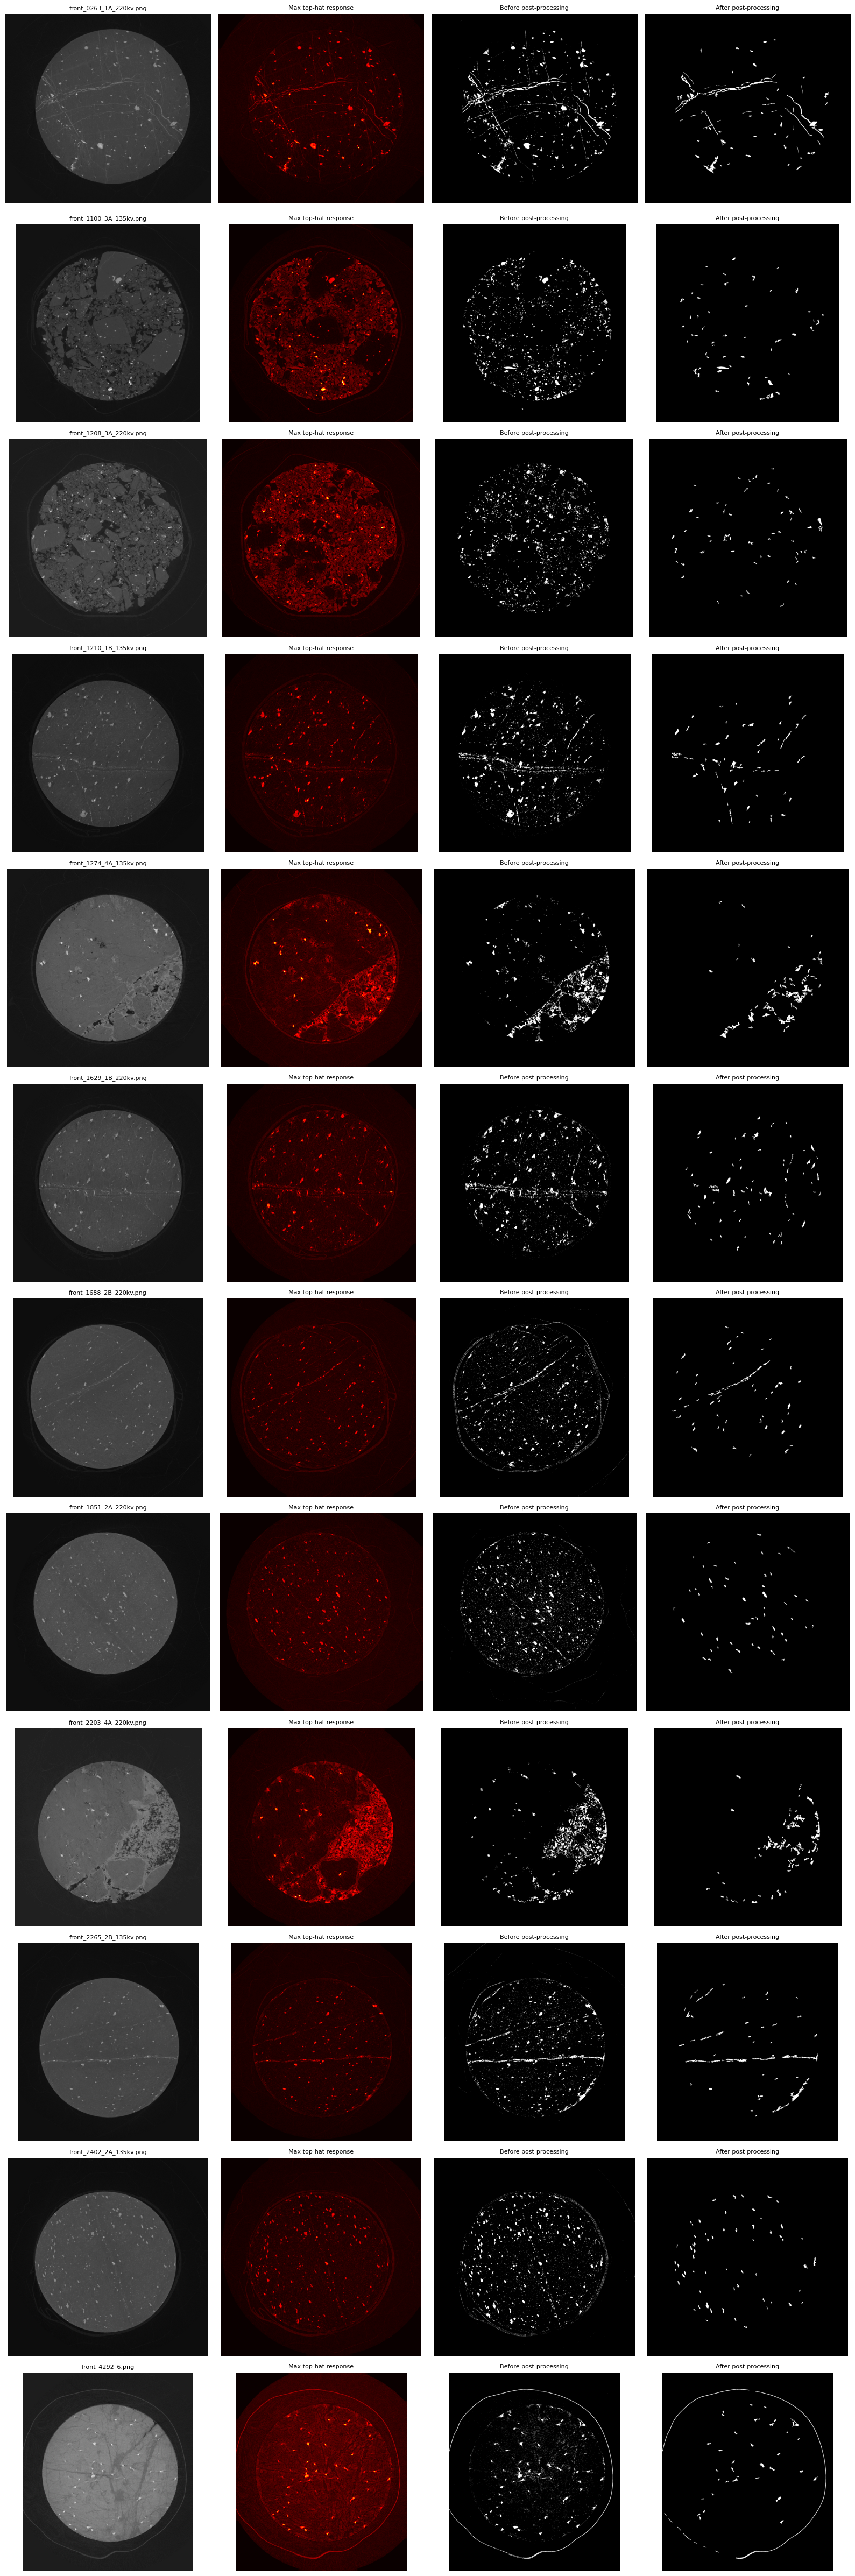

In [18]:
fig, axes = plt.subplots(len(images), 4, figsize=(16, 4 * len(images)))
if len(images) == 1:
    axes = [axes]

for ax_row, img_path in zip(axes, images):
    img      = load_grayscale(img_path)
    response = apply_tophat_bank(img, se_bank)
    binary   = threshold_response(response)
    mask     = postprocess(binary)

    ax_row[0].imshow(img, cmap="gray")
    ax_row[0].set_title(img_path.name, fontsize=8)
    ax_row[0].axis("off")

    ax_row[1].imshow(response, cmap="hot")
    ax_row[1].set_title("Max top-hat response", fontsize=8)
    ax_row[1].axis("off")

    ax_row[2].imshow(binary, cmap="gray")
    ax_row[2].set_title("Before post-processing", fontsize=8)
    ax_row[2].axis("off")

    ax_row[3].imshow(mask, cmap="gray")
    ax_row[3].set_title("After post-processing", fontsize=8)
    ax_row[3].axis("off")

plt.tight_layout()
plt.show()